In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-10 10:51:19.786297


# Recluster neurons

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04a_neurons"
adata_path = input_dir / "scanvi_neuron_adata.h5ad"
bdata_path = input_dir / "seurat_neuron_adata.h5ad"

output_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
adata = sc.read_h5ad(adata_path)
bdata = sc.read_h5ad(bdata_path)

In [6]:
print(adata)
print("-"*40)
print(bdata)

AnnData object with n_obs × n_vars = 22133 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

# Neighbors graph

In [7]:
sc.pp.neighbors(adata, use_rep = 'X_scVI_scanvi_neuron', random_state = 0)
sc.pp.neighbors(bdata, use_rep = 'X_scVI_seurat_neuron', random_state = 0)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sc.tl.umap(adata, random_state = 0)
sc.tl.umap(bdata, random_state = 0)

In [9]:
sc.tl.leiden(adata, key_added='neuron_recluster_scanvi', resolution=0.25)
sc.tl.leiden(bdata, key_added='neuron_recluster_seurat', resolution=0.25)

/tmp/ipykernel_5376/3783692772.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='neuron_recluster_scanvi', resolution=0.25)


In [10]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [11]:
assign_cell_type_colors(adata,  key="scanvi_labels")
assign_cell_type_colors(adata,  key="seurat_labels")
assign_cell_type_colors(bdata,  key="scanvi_labels")
assign_cell_type_colors(bdata,  key="seurat_labels")

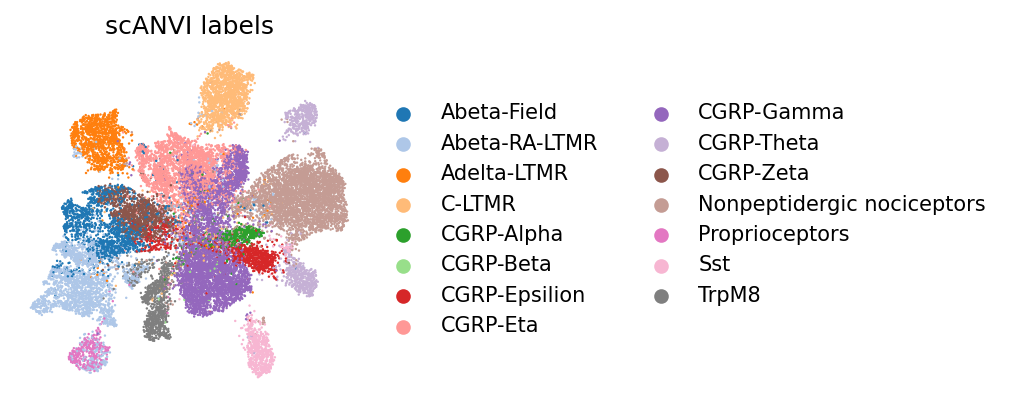

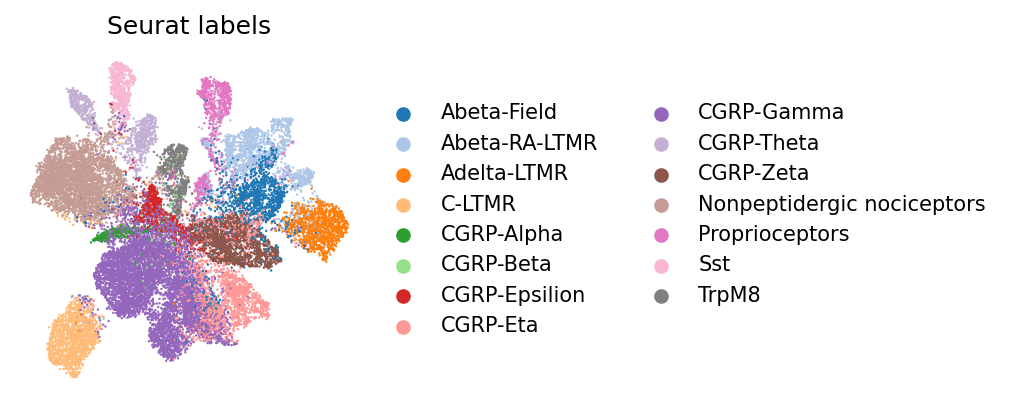

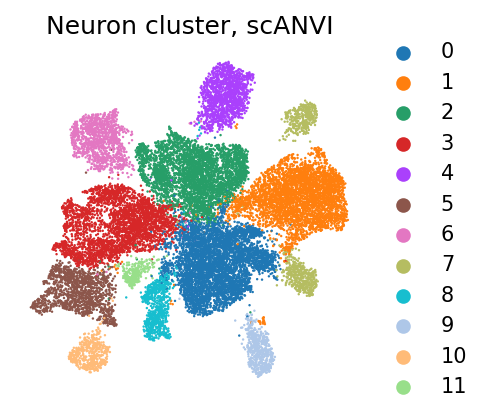

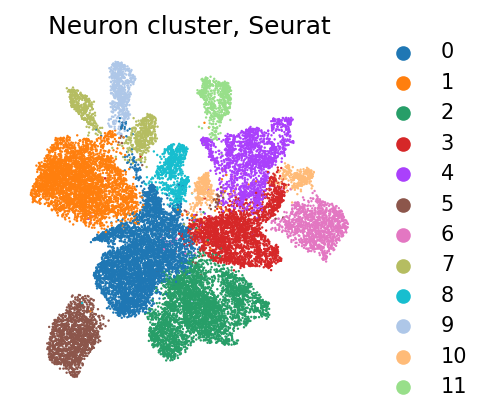

In [12]:
sc.pl.umap(adata, color = 'scanvi_labels', frameon = False, title = 'scANVI labels')
sc.pl.umap(bdata, color = 'seurat_labels', frameon = False, title = 'Seurat labels')
sc.pl.umap(adata, color = 'neuron_recluster_scanvi', frameon = False, title = 'Neuron cluster, scANVI')
sc.pl.umap(bdata, color = 'neuron_recluster_seurat', frameon = False, title = 'Neuron cluster, Seurat')

# Summary

In [13]:
# scANVI summary
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "confidence": adata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

df[df["EGFP_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
aogalboa-1,aogalboa-1,CGRP-Gamma,CGRP-Eta,NaN
ahgdffna-1,ahgdffna-1,CGRP-Eta,CGRP-Eta,NaN
canljbbi-1,canljbbi-1,CGRP-Gamma,CGRP-Gamma,NaN
eaiehejo-1,eaiehejo-1,Abeta-Field,Adelta-LTMR,NaN
ihadecfn-1,ihadecfn-1,CGRP-Gamma,CGRP-Gamma,NaN
ilophdlj-1,ilophdlj-1,CGRP-Zeta,CGRP-Zeta,NaN
lllnlabg-1,lllnlabg-1,CGRP-Gamma,CGRP-Gamma,NaN
lnbkkcoo-1,lnbkkcoo-1,CGRP-Gamma,CGRP-Gamma,NaN
hjaemfbm-1,hjaemfbm-1,CGRP-Gamma,CGRP-Gamma,NaN
aefdhdnh-1,aefdhdnh-1,Adelta-LTMR,Adelta-LTMR,NaN


In [14]:
df[df["dTom_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
achecihm-1,achecihm-1,CGRP-Gamma,CGRP-Gamma,NaN
aemkjdhf-1,aemkjdhf-1,CGRP-Gamma,CGRP-Gamma,NaN
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
bekmepom-1,bekmepom-1,CGRP-Gamma,CGRP-Gamma,NaN
bjfneajg-1,bjfneajg-1,CGRP-Gamma,CGRP-Gamma,NaN
...,...,...,...,...
apodpaed-1,apodpaed-1,CGRP-Gamma,CGRP-Gamma,NaN
dhlbnpjp-1,dhlbnpjp-1,CGRP-Gamma,CGRP-Eta,NaN
gkcjkgon-1,gkcjkgon-1,CGRP-Gamma,CGRP-Gamma,NaN
jmdegfji-1,jmdegfji-1,CGRP-Gamma,CGRP-Gamma,NaN


In [15]:
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High
ajnphbmj-1,ajnphbmj-1,CGRP-Gamma,CGRP-Gamma,NaN


In [16]:
# Seurat summary
egfp = bdata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = bdata.obs["dTomato_Seq2_hi"].astype(bool)
dual = bdata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": bdata.obs.index,
    "seurat_label": bdata.obs["seurat_labels"],
    "scanvi_label": bdata.obs["scanvi_labels"],
    "confidence": bdata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

df[df["EGFP_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
aogalboa-1,aogalboa-1,CGRP-Gamma,CGRP-Eta,NaN
ckgddhbd-1,ckgddhbd-1,CGRP-Eta,SGC,NaN
ahgdffna-1,ahgdffna-1,CGRP-Eta,CGRP-Eta,NaN
akfjbdhd-1,akfjbdhd-1,TrpM8,Pericyte,NaN
canljbbi-1,canljbbi-1,CGRP-Gamma,CGRP-Gamma,NaN
eaiehejo-1,eaiehejo-1,Abeta-Field,Adelta-LTMR,NaN
ihadecfn-1,ihadecfn-1,CGRP-Gamma,CGRP-Gamma,NaN
ilophdlj-1,ilophdlj-1,CGRP-Zeta,CGRP-Zeta,NaN
lllnlabg-1,lllnlabg-1,CGRP-Gamma,CGRP-Gamma,NaN
llneboie-1,llneboie-1,Proprioceptors,Pericyte,NaN


In [17]:
df[df["dTom_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
achecihm-1,achecihm-1,CGRP-Gamma,CGRP-Gamma,NaN
aemkjdhf-1,aemkjdhf-1,CGRP-Gamma,CGRP-Gamma,NaN
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
behbjfkc-1,behbjfkc-1,CGRP-Gamma,Pericyte,NaN
bekmepom-1,bekmepom-1,CGRP-Gamma,CGRP-Gamma,NaN
...,...,...,...,...
apodpaed-1,apodpaed-1,CGRP-Gamma,CGRP-Gamma,NaN
dhlbnpjp-1,dhlbnpjp-1,CGRP-Gamma,CGRP-Eta,NaN
gkcjkgon-1,gkcjkgon-1,CGRP-Gamma,CGRP-Gamma,NaN
jmdegfji-1,jmdegfji-1,CGRP-Gamma,CGRP-Gamma,NaN


In [18]:
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High
ajnphbmj-1,ajnphbmj-1,CGRP-Gamma,CGRP-Gamma,NaN


# Export

In [19]:
adata_path = os.path.join(output_dir, 'neurons-scanvi.h5ad')
bdata_path = os.path.join(output_dir, 'neurons-seurat.h5ad')

adata.write_h5ad(adata_path, compression='gzip') # didnt run 12/9 evening
bdata.write_h5ad(bdata_path, compression='gzip')

print(adata_path)
print(bdata_path)

/home/workspace/projects/drg/data/h5ad/export_04/04b_reclustered/neurons-scanvi.h5ad
/home/workspace/projects/drg/data/h5ad/export_04/04b_reclustered/neurons-seurat.h5ad


## Session info

In [20]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [21]:
adata

AnnData object with n_obs × n_vars = 22133 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

# test recompute neighbors use scanvi

In [22]:
sc.pl.umap(bdata, color = ['neuron_recluster', 'seurat_labels'], frameon = False, title = 'scANVI labels')

KeyError: 'neuron_recluster'

<Figure size 1143x450 with 0 Axes>

In [ ]:
bdata.obs.EGFP_dTomato_dual_hi.value_counts()

In [ ]:
bdata_subset = bdata[bdata.obs['total_counts'] > 1000].copy()
sc.pl.umap(bdata_subset, color = 'seurat_labels', frameon = False, title = 'scANVI labels')

In [ ]:
bdata_subset.obs.EGFP_dTomato_dual_hi.value_counts()

# test

In [ ]:
bdata_copy = bdata.copy()

In [ ]:
bdata.X = bdata.layers['log1p'].copy()

In [ ]:
sc.pp.regress_out(bdata, ["total_counts"])
sc.pp.scale(bdata, max_value=10)

In [ ]:
sc.pp.pca(bdata, n_comps = 10)
sc.pp.neighbors(bdata,random_state = 0, n_neighbors = 10)
#sc.pp.neighbors(bdata,random_state = 0, use_rep = 'X_scVI_seurat_neuron', n_neighbors = 30)


In [ ]:
sc.tl.umap(bdata, random_state = 0)

In [ ]:
sc.pl.umap(bdata, color = 'seurat_labels', frameon = False, title = 'scANVI labels')

In [ ]:
import matplotlib.pyplot as plt

# Column to visualize
col = "EGFP_dTomato_dual_hi"

# Get UMAP coordinates
x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

# Boolean mask
mask = adata.obs[col].astype(bool).values

plt.figure(figsize=(3, 3))

# Plot FALSE (background)
plt.scatter(
    x[~mask],
    y[~mask],
    s=5,
    c="lightgray",
    linewidths=0,
    alpha=0.4,
)

# Plot TRUE (highlight)
plt.scatter(
    x[mask],
    y[mask],
    s=25,
    c="red",         # ← change color if you want
    edgecolors="black",
    linewidths=0.6,
    alpha=1.0,
)

# Minimalist formatting
ax = plt.gca()
ax.set_aspect("equal", "box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Column to visualize
col = "EGFP_dTomato_dual_hi"

# Get UMAP coordinates
x, y = bdata.obsm["X_umap"][:, 0], bdata.obsm["X_umap"][:, 1]

# Boolean mask
mask = bdata.obs[col].astype(bool).values

plt.figure(figsize=(3, 3))

# Plot FALSE (background)
plt.scatter(
    x[~mask],
    y[~mask],
    s=5,
    c="lightgray",
    linewidths=0,
    alpha=0.4,
)

# Plot TRUE (highlight)
plt.scatter(
    x[mask],
    y[mask],
    s=25,
    c="red",         # ← change color if you want
    edgecolors="black",
    linewidths=0.6,
    alpha=1.0,
)

# Minimalist formatting
ax = plt.gca()
ax.set_aspect("equal", "box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
sc.pl.umap(bdata, color = ['total_counts', 'scanvi_labels', 'neuron_recluster_seurat'], frameon = False, title = 'scANVI labels')

In [ ]:
adata

In [ ]:
import scanpy as sc
import pandas as pd
adata_neuron = adata.copy()
# Make sure the cluster column is categorical
adata_neuron.obs["neuron_recluster_scanvi"] = (
    adata_neuron.obs["neuron_recluster_scanvi"].astype("category")
)

# Identify cluster labels
cluster_col = "neuron_recluster_scanvi"
cluster_0 = adata_neuron[adata_neuron.obs[cluster_col] == "2"]
cluster_2 = adata_neuron[adata_neuron.obs[cluster_col] == "0"]

# Combine them into one AnnData so Scanpy can compare
adata_pair = adata_neuron[
    adata_neuron.obs[cluster_col].isin(["2", "0"])
].copy()

# Run DE test
sc.tl.rank_genes_groups(
    adata_pair,
    groupby=cluster_col,
    groups=["2"],     # compare group 0 …
    reference="0",    # … against group 2
    method="wilcoxon"
)

# Extract the DEG table
deg = sc.get.rank_genes_groups_df(adata_pair, group="2")

# Show top 20 genes
deg.head(20)

In [ ]:
adata.obs.scanvi_labels.value_counts()

In [ ]:
import pandas as pd

# Boolean mask for dual-positive cells
dual_mask = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

# Build a small dataframe for only dual-positive rows
df_dual = pd.DataFrame({
    "barcode": adata.obs.index[dual_mask],
    #"seurat_label": adata.obs["seurat_labels"][dual_mask],
    "scanvi_label": adata.obs["scanvi_labels"][dual_mask],
    "neuron_recluster": adata.obs["neuron_recluster_scanvi"][dual_mask],
    "total_counts": adata.obs["total_counts"][dual_mask],
})

df_dual

# DEGs - dual positive vs. rest

In [23]:
import scanpy as sc
import pandas as pd

# Ensure boolean mask exists
dual_mask = adata_neuron.obs["EGFP_dTomato_dual_hi"].astype(bool)

# Label dual vs non-dual neurons
adata_neuron.obs["dual_group"] = dual_mask.map({True: "Dual", False: "NonDual"}).astype("category")

# Run differential expression (Dual vs NonDual)
sc.tl.rank_genes_groups(
    adata_neuron,
    groupby="dual_group",
    groups=["Dual"],          # Dual positive …
    reference="NonDual",      # … compared to all other neurons
    method="wilcoxon"
)

# Extract results as a dataframe
deg = sc.get.rank_genes_groups_df(adata_neuron, group="Dual")

# Show top 20 genes
print("\nTop DE genes (Dual vs NonDual):")
display(deg.head(20))

# Plot DE visualization
sc.pl.rank_genes_groups(adata_neuron, n_genes=20, sharey=False)

NameError: name 'adata_neuron' is not defined

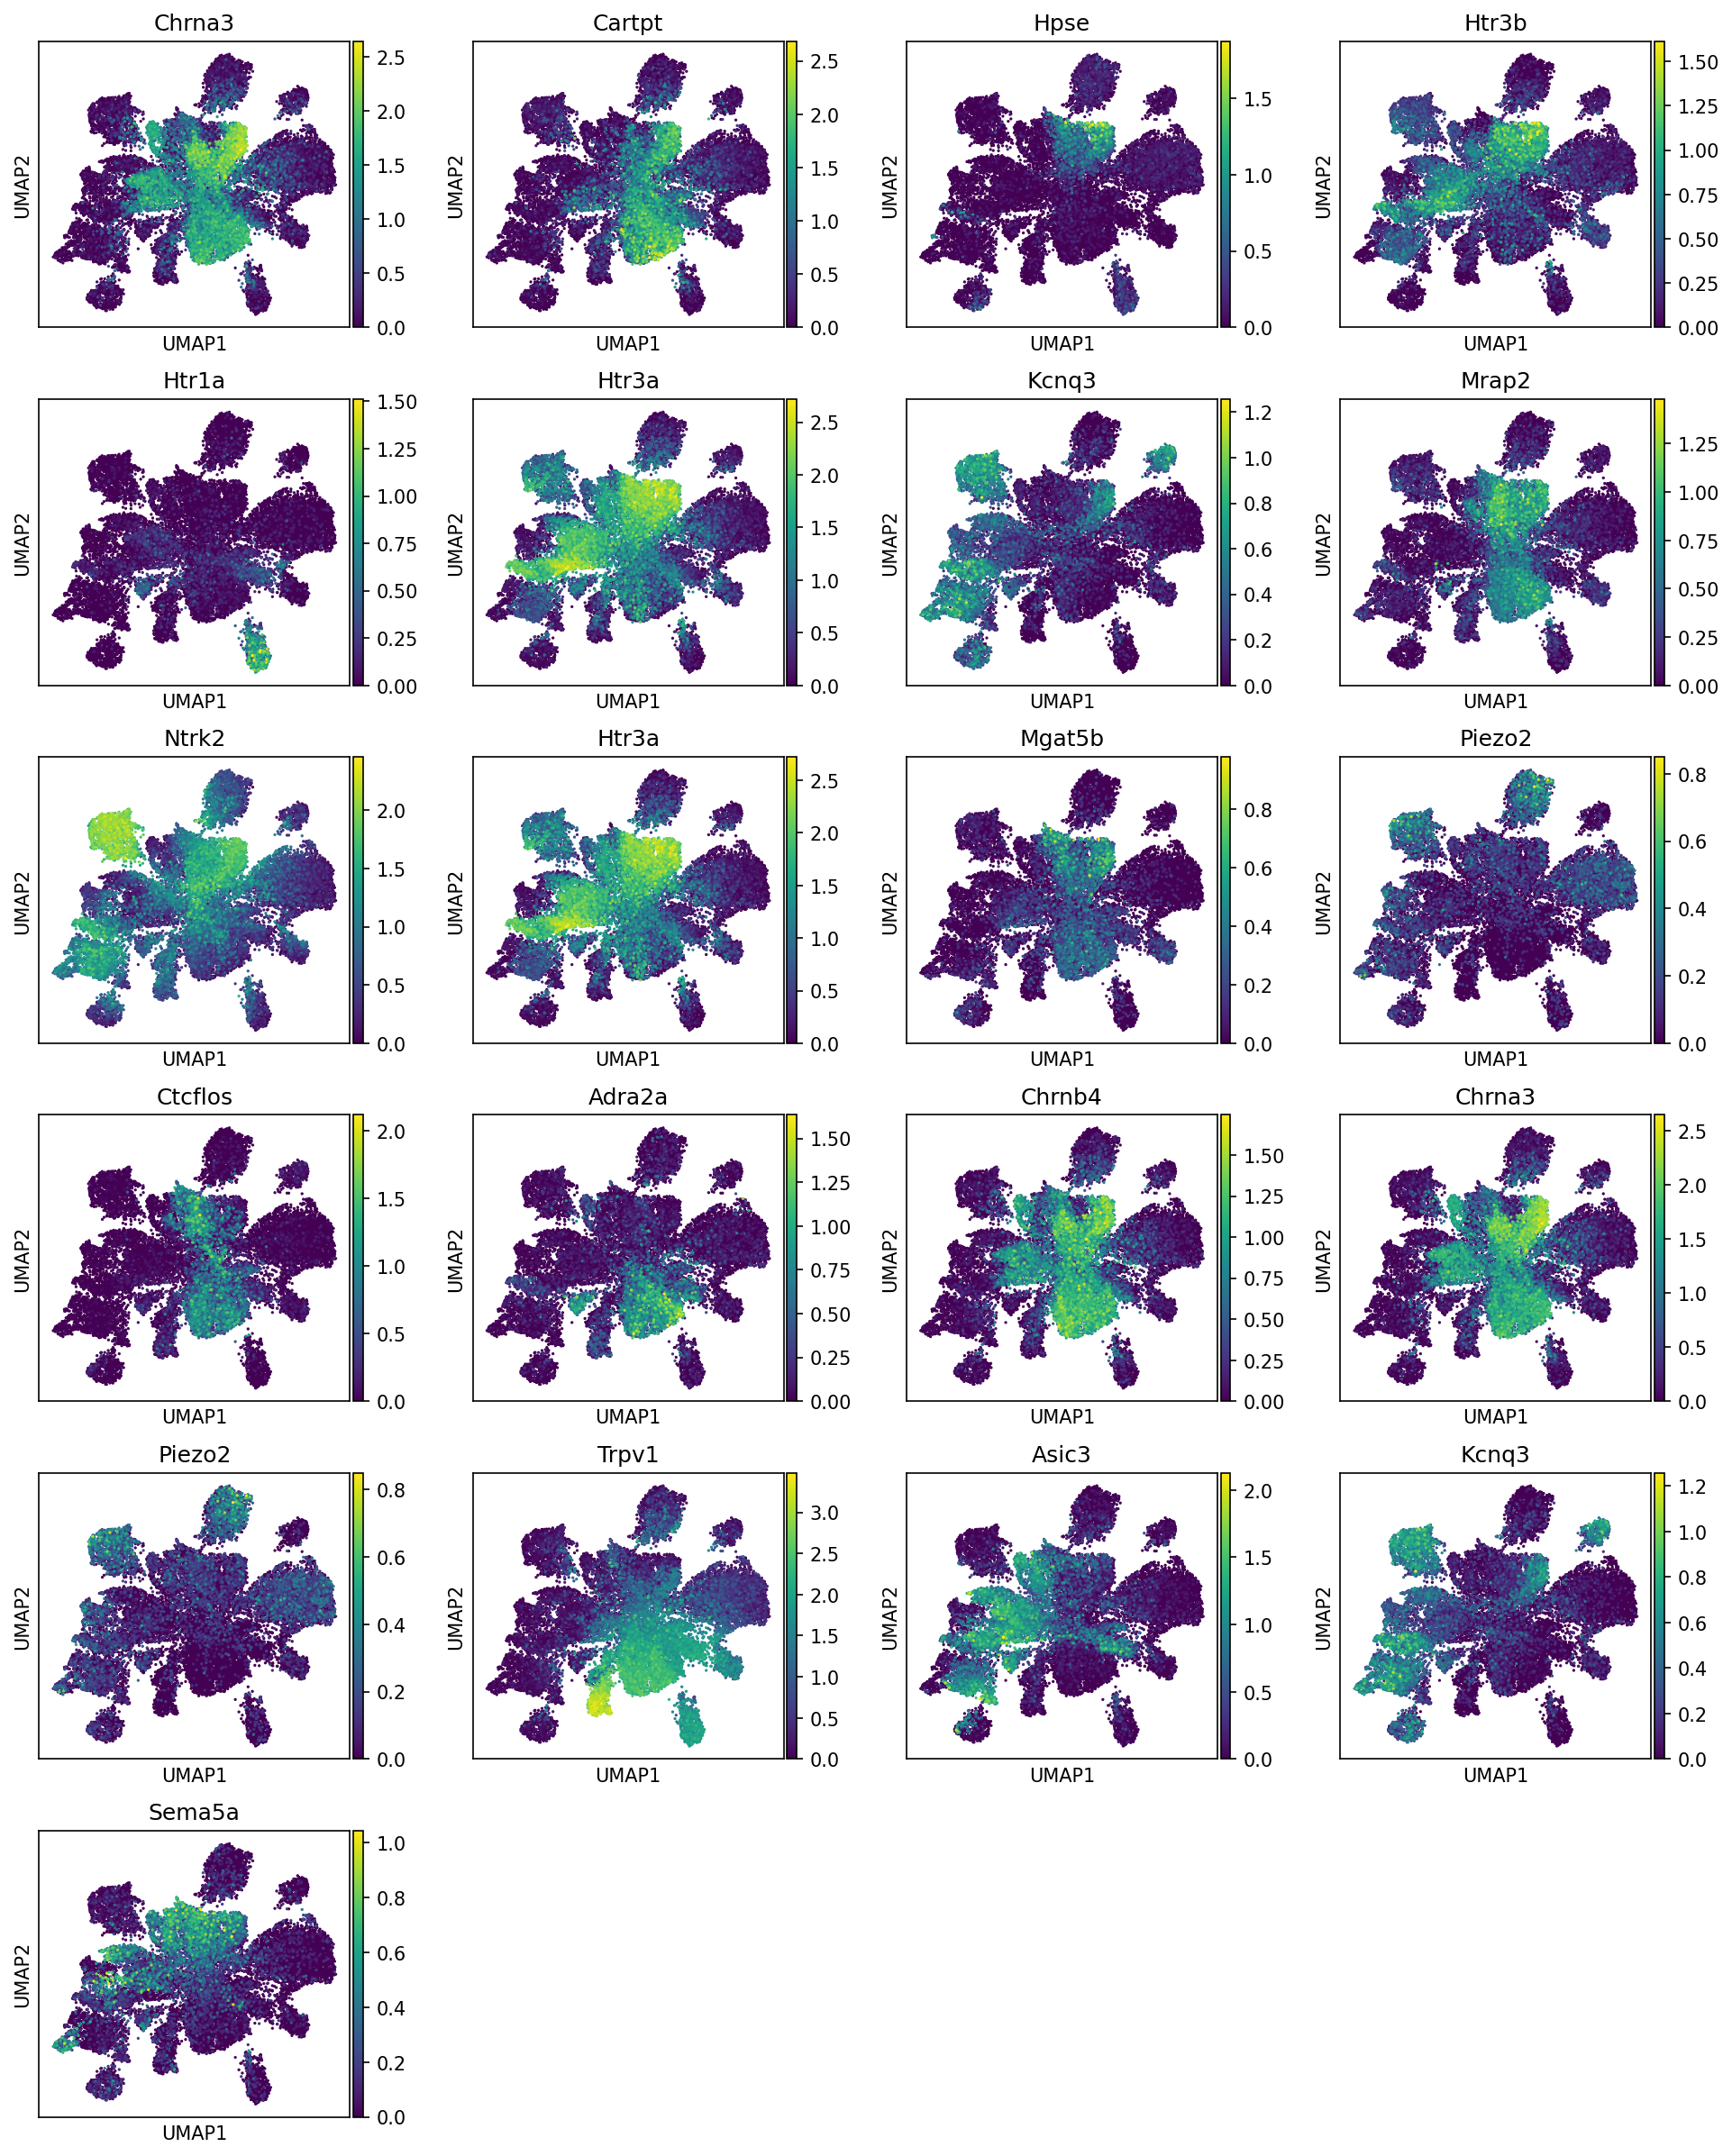

In [24]:
sc.pl.umap(adata, color = ['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Htr1a', 'Htr3a', 'Kcnq3', 'Mrap2', 'Ntrk2', 'Htr3a', 'Mgat5b', 'Piezo2', 'Ctcflos', 'Adra2a', 'Chrnb4', 'Chrna3', 'Piezo2', 'Trpv1', 'Asic3', 'Kcnq3', 'Sema5a'], size = 10)

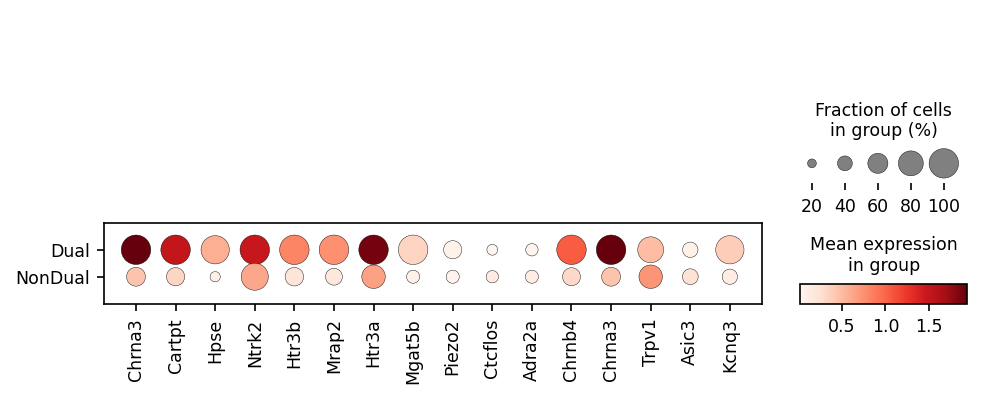

In [25]:
# Convert boolean → string category
adata.obs["dual_str"] = adata.obs["EGFP_dTomato_dual_hi"].map(
    {True: "Dual", False: "NonDual"}
).astype("category")

# Now plot using the string grouping column
sc.pl.dotplot(
    adata,
    var_names=['Chrna3', 'Cartpt', 'Hpse', 'Ntrk2', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Piezo2', 'Ctcflos', 'Adra2a', 'Chrnb4', 'Chrna3', 'Trpv1', 'Asic3', 'Kcnq3'],
    groupby="dual_str"#, standard_scale = 'var'
)

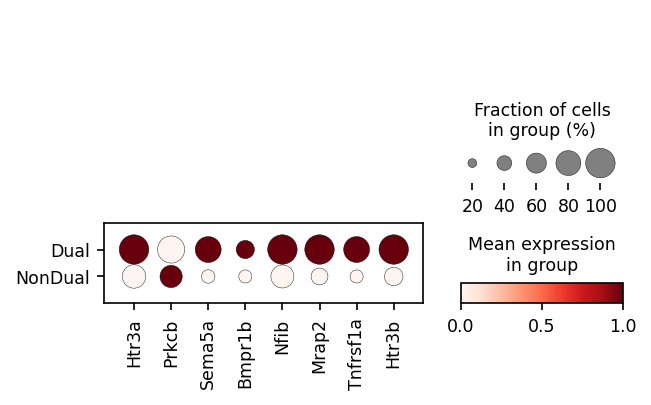

In [26]:
# Convert boolean → string category
adata.obs["dual_str"] = adata.obs["EGFP_dTomato_dual_hi"].map(
    {True: "Dual", False: "NonDual"}
).astype("category")

# Now plot using the string grouping column
sc.pl.dotplot(
    adata,
    var_names=['Htr3a', 'Prkcb', 'Sema5a', 'Bmpr1b', 'Nfib', 'Mrap2', 'Tnfrsf1a', 'Htr3b'],
    groupby="dual_str", standard_scale = 'var'
)


In [ ]:
# Now plot using the string grouping column
sc.pl.dotplot(
    adata,
    var_names=['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Piezo2', 'Ctcflos', 'Adra2a', 'Chrnb4', 'Chrna3'],
    groupby="scanvi_labels", standard_scale = 'var'
)

In [ ]:
import scanpy as sc
import pandas as pd

# --- parameters ---
cluster_col = "neuron_recluster_scanvi"
cluster_to_compare = "2"   # your cluster of interest
dual_col = "EGFP_dTomato_dual_hi"

# --- 1. Boolean masks ---
is_cluster = adata.obs[cluster_col].astype(str) == cluster_to_compare
dual_mask = adata.obs[dual_col].astype(bool)

# --- 2. Subset to cluster 2 ---
adata_c2 = adata[is_cluster].copy()

# --- 3. Label Dual vs NonDual within cluster 2 ---
adata_c2.obs["dual_group"] = dual_mask[is_cluster].map(
    {True: "Dual", False: "NonDual"}
).astype("category")

# --- 4. Check group sizes ---
group_counts = adata_c2.obs["dual_group"].value_counts()
print("\nGroup sizes in cluster 2:")
print(group_counts, "\n")

if ("Dual" not in group_counts.index) or ("NonDual" not in group_counts.index):
    print("❌ One of the groups is missing in cluster 2.")
elif (group_counts["Dual"] < 2) or (group_counts["NonDual"] < 2):
    print("❌ Not enough cells. Each group needs ≥2 for Wilcoxon.")
else:
    # --- 5. Run DE ---
    print("✔ Running Wilcoxon DE: Dual vs NonDual inside cluster 2")
    sc.tl.rank_genes_groups(
        adata_c2,
        groupby="dual_group",
        groups=["Dual"],
        reference="NonDual",
        method="wilcoxon",
    )

    # --- 6. Extract results ---
    deg = sc.get.rank_genes_groups_df(adata_c2, group="Dual")

    print("\nTop DE genes (Dual vs NonDual in cluster 2):\n")
    display(deg.head(20))

    # --- 7. Plot ---
    sc.pl.rank_genes_groups(adata_c2, n_genes=20, sharey=False)

In [ ]:
import scanpy as sc
import pandas as pd

# Make sure scanvi_labels is categorical
adata.obs["scanvi_labels"] = adata.obs["scanvi_labels"].astype("category")

print("Scanvi label counts:")
print(adata.obs["scanvi_labels"].value_counts(), "\n")

# Run Wilcoxon DE on scanvi_labels
sc.tl.rank_genes_groups(
    adata,
    groupby="scanvi_labels",
    method="wilcoxon"
)

# Extract marker table for ALL scanvi labels
markers = sc.get.rank_genes_groups_df(adata, None)
print("Top markers per scanvi label:")
display(markers.head(20))

# Plot top 20 markers
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [ ]:
import scanpy as sc
import pandas as pd

cluster_col = "neuron_recluster_scanvi"

# make sure categorical
adata.obs[cluster_col] = adata.obs[cluster_col].astype("category")

print("Cluster counts:")
print(adata.obs[cluster_col].value_counts(), "\n")

# run DE: cluster 2 vs rest
sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_col,
    groups=["2"],    # cluster of interest
    reference="rest",
    method="wilcoxon"
)

# extract table
markers_c2 = sc.get.rank_genes_groups_df(adata, group="2")
print("Top DE markers: cluster 2 vs ALL other clusters")
display(markers_c2.head(30))

# plot top 20
sc.pl.rank_genes_groups(adata, groups=["2"], n_genes=20, sharey=False)

In [ ]:
['Htr3a', 'Prkcb', 'Sema5a', 'Bmpr1b', 'Nfib', 'Mrap2', 'Tnfrsf1a', 'Htr3b']